# Evaluating the Impact of Data Cleaning Strategies on Customer Churn Prediction

Dataset : https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset

In [ ]:
# Importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Import the data

df=pd.read_excel("Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
print("Shape:", df.shape)

Shape: (7043, 33)


In [ ]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100
}).sort_values(by="missing_count", ascending=False)

missing_summary

,missing_count,missing_percent
Churn Reason,5174,73.463013
CustomerID,0,0.000000
Count,0,0.000000
State,0,0.000000
Country,0,0.000000
Zip Code,0,0.000000
Lat Long,0,0.000000
Latitude,0,0.000000
City,0,0.000000
Gender,0,0.000000


In [ ]:
(df == "").sum().sort_values(ascending=False)

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [ ]:
df["Churn Label"].value_counts(normalize=True)

,proportion
Churn Label,
No,0.73463
Yes,0.26537


In [ ]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical columns:", num_cols)
print("\nCategorical columns:", cat_cols)

Numerical columns: ['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']

Categorical columns: ['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges', 'Churn Label', 'Churn Reason']


In [ ]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


In [ ]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    outlier_summary[col] = outliers

pd.Series(outlier_summary).sort_values(ascending=False)

,0
Count,0
Zip Code,0
Latitude,0
Longitude,0
Tenure Months,0
Monthly Charges,0
Churn Value,0
Churn Score,0
CLTV,0


In [ ]:
df.duplicated().sum()

np.int64(0)

## FEATURE PRUNING AND TYPE CORRECTION

In [ ]:
cols_to_drop = [
    "CustomerID", "Count", "Country", "State", "City", "Zip Code",
    "Lat Long", "Latitude", "Longitude",
    "Churn Reason", "Churn Value", "Churn Score", "CLTV"
]

df_step2 = df.drop(columns=cols_to_drop)

print("Shape after dropping columns:", df_step2.shape)
df_step2.head()

Shape after dropping columns: (7043, 20)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes


In [ ]:
df_step2["Total Charges"] = pd.to_numeric(
    df_step2["Total Charges"], errors="coerce"
)

df_step2["Total Charges"].dtype

dtype('float64')

In [ ]:
missing_summary_step2 = pd.DataFrame({
    "missing_count": df_step2.isnull().sum(),
    "missing_percent": df_step2.isnull().mean() * 100
}).sort_values(by="missing_count", ascending=False)

missing_summary_step2

,missing_count,missing_percent
Total Charges,11,0.156183
Gender,0,0.000000
Partner,0,0.000000
Senior Citizen,0,0.000000
Dependents,0,0.000000
Tenure Months,0,0.000000
Multiple Lines,0,0.000000
Phone Service,0,0.000000
Online Security,0,0.000000
Online Backup,0,0.000000


In [ ]:
y = df_step2["Churn Label"]
X = df_step2.drop(columns=["Churn Label"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [ ]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical columns:", num_cols)
print("\nCategorical columns:", cat_cols)

Numerical columns: ['Tenure Months', 'Monthly Charges', 'Total Charges']

Categorical columns: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [ ]:
df_step2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

## DEFINING CLEANING STRATEGIES



In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Sanity check
dict(zip(le.classes_, le.transform(le.classes_)))

{'No': np.int64(0), 'Yes': np.int64(1)}

In [ ]:
numeric_features = ["Tenure Months", "Monthly Charges", "Total Charges"]
categorical_features = [col for col in X.columns if col not in numeric_features]

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['Tenure Months', 'Monthly Charges', 'Total Charges']
Categorical: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [ ]:
# missing value strategies

from sklearn.impute import SimpleImputer, KNNImputer

num_imputer_median = SimpleImputer(strategy="median")
num_imputer_knn = KNNImputer(n_neighbors=5)

In [ ]:
# scaling strategies

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [ ]:
# categorical preprocessing (fixed for all pipelines)

from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

def make_preprocessor(num_imputer, use_scaling):
    num_steps = [("imputer", num_imputer)]

    if use_scaling:
        num_steps.append(("scaler", scaler))

    numeric_pipeline = Pipeline(steps=num_steps)

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", cat_encoder, categorical_features)
        ]
    )

    return preprocessor

In [ ]:
cleaning_strategies = {
    "median_no_scaling": make_preprocessor(num_imputer_median, False),
    "median_with_scaling": make_preprocessor(num_imputer_median, True),
    "knn_no_scaling": make_preprocessor(num_imputer_knn, False),
    "knn_with_scaling": make_preprocessor(num_imputer_knn, True)
}

## MODEL TRAINING AND EVALUATION

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

print(X_train.shape, X_test.shape)

(5634, 19) (1409, 19)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    solver="liblinear"
)

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

In [ ]:
from sklearn.pipeline import Pipeline
import pandas as pd

results = []

for name, preprocessor in cleaning_strategies.items():

    pipeline = Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    # Fit
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    results.append({
        "Pipeline": name,
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by="ROC_AUC", ascending=False)
results_df

,Pipeline,ROC_AUC,F1,Precision,Recall,Accuracy
2,knn_no_scaling,0.849368,0.609442,0.655385,0.569519,0.806246
0,median_no_scaling,0.849242,0.608819,0.650456,0.572193,0.804826
3,knn_with_scaling,0.848901,0.603399,0.641566,0.569519,0.801278
1,median_with_scaling,0.848754,0.605375,0.642643,0.572193,0.801987


## VISUALIZATION

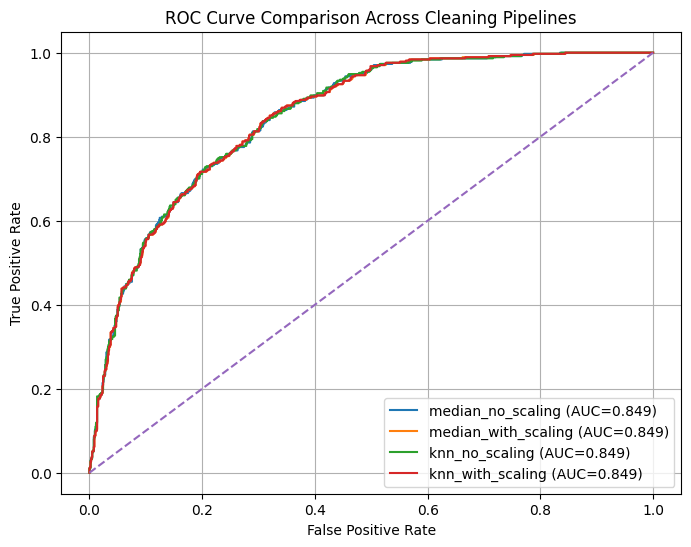

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, preprocessor in cleaning_strategies.items():

    pipeline = Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_proba = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    auc_score = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")

# Baseline
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison Across Cleaning Pipelines")
plt.legend()
plt.grid(True)
plt.show()